## **1. Import thư viện**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **2. Đọc dữ liệu và khám phá tổng quan**

In [3]:
train = pd.read_csv("../../data/train (1).csv")
test = pd.read_csv("../../data/test (2).csv")

In [4]:
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14396 entries, 0 to 14395
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Id                  14396 non-null  int64  
 1   Artist Name         14396 non-null  object 
 2   Track Name          14396 non-null  object 
 3   Popularity          14063 non-null  float64
 4   danceability        14396 non-null  float64
 5   energy              14396 non-null  float64
 6   key                 12787 non-null  float64
 7   loudness            14396 non-null  float64
 8   mode                14396 non-null  int64  
 9   speechiness         14396 non-null  float64
 10  acousticness        14396 non-null  float64
 11  instrumentalness    10855 non-null  float64
 12  liveness            14396 non-null  float64
 13  valence             14396 non-null  float64
 14  tempo               14396 non-null  float64
 15  duration_in min/ms  14396 non-null  float64
 16  time

In [5]:
display(train.describe())

,Id,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
count,14396.000000,14063.000000,14396.000000,14396.000000,12787.000000,14396.000000,14396.000000,14396.000000,14396.000000,10855.000000,14396.000000,14396.000000,14396.000000,1.439600e+04,14396.000000,14396.000000
mean,7198.500000,44.525208,0.543105,0.662422,5.953781,-7.900852,0.640247,0.080181,0.246746,0.178129,0.195782,0.486379,122.695372,2.000942e+05,3.924354,6.695679
std,4155.911573,17.418940,0.165517,0.235967,3.200013,4.057362,0.479944,0.085157,0.310922,0.304266,0.159258,0.239476,29.538490,1.116891e+05,0.359520,3.206170
min,1.000000,1.000000,0.059600,0.001210,1.000000,-39.952000,0.000000,0.022500,0.000000,0.000001,0.011900,0.021500,30.557000,5.016500e-01,1.000000,0.000000
25%,3599.750000,33.000000,0.432000,0.508000,3.000000,-9.538000,0.000000,0.034800,0.004280,0.000088,0.097275,0.299000,99.799000,1.654458e+05,4.000000,5.000000
50%,7198.500000,44.000000,0.545000,0.699000,6.000000,-7.013500,1.000000,0.047100,0.081450,0.003920,0.129000,0.480500,120.060000,2.089410e+05,4.000000,8.000000
75%,10797.250000,56.000000,0.658000,0.861000,9.000000,-5.162000,1.000000,0.083100,0.432250,0.201000,0.256000,0.672000,141.988250,2.522470e+05,4.000000,10.000000
max,14396.000000,100.000000,0.989000,1.000000,11.000000,1.342000,1.000000,0.955000,0.996000,0.996000,0.992000,0.986000,217.416000,1.477187e+06,5.000000,10.000000


In [6]:
train.describe(include=['object'])

,Artist Name,Track Name
count,14396,14396
unique,7913,12455
top,Backstreet Boys,Fire
freq,58,8


In [7]:
display(train.head())
display(test.head())

,Id,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
0,1,Marina Maximilian,Not Afraid,37.0,0.334,0.536,9.0,-6.649,0,0.0381,0.378000,NaN,0.106,0.235,152.429,204947.0,4,9
1,2,The Black Keys,Howlin' for You,67.0,0.725,0.747,11.0,-5.545,1,0.0876,0.027200,0.0468,0.104,0.380,132.921,191956.0,4,6
2,3,Royal & the Serpent,phuck u,NaN,0.584,0.804,7.0,-6.094,1,0.0619,0.000968,0.6350,0.284,0.635,159.953,161037.0,4,10
3,4,Detroit Blues Band,Missing You,12.0,0.515,0.308,NaN,-14.711,1,0.0312,0.907000,0.0213,0.300,0.501,172.472,298093.0,3,2
4,5,Coast Contra,My Lady,48.0,0.565,0.777,6.0,-5.096,0,0.2490,0.183000,NaN,0.211,0.619,88.311,254145.0,4,5


,Id,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature
0,14397,Juan Pablo Vega,Matando (feat. Vic Mirallas),NaN,0.691,0.670,2.0,-7.093,0,0.0941,0.075700,0.035200,0.1970,0.635,89.965,200000.0,4
1,14398,Kappi Kat,Baarish,14.0,0.461,0.777,2.0,-7.469,1,0.0306,0.388000,0.923000,0.2910,0.525,163.043,283909.0,4
2,14399,Plain White T's,Hey There Delilah,80.0,0.656,0.291,2.0,-10.572,1,0.0293,0.872000,NaN,0.1140,0.298,103.971,232533.0,4
3,14400,WALK THE MOON,Different Colors,52.0,0.480,0.826,NaN,-4.602,1,0.0397,0.000797,0.000001,0.1250,0.687,96.000,222053.0,4
4,14401,Peled,◊ß◊®◊ô◊ñ,23.0,0.734,0.729,1.0,-6.381,0,0.2830,0.147000,NaN,0.0672,0.805,76.030,118439.0,4


Tỷ lệ missing values (%):
instrumentalness    24.597110
key                 11.176716
Popularity           2.313143
dtype: float64


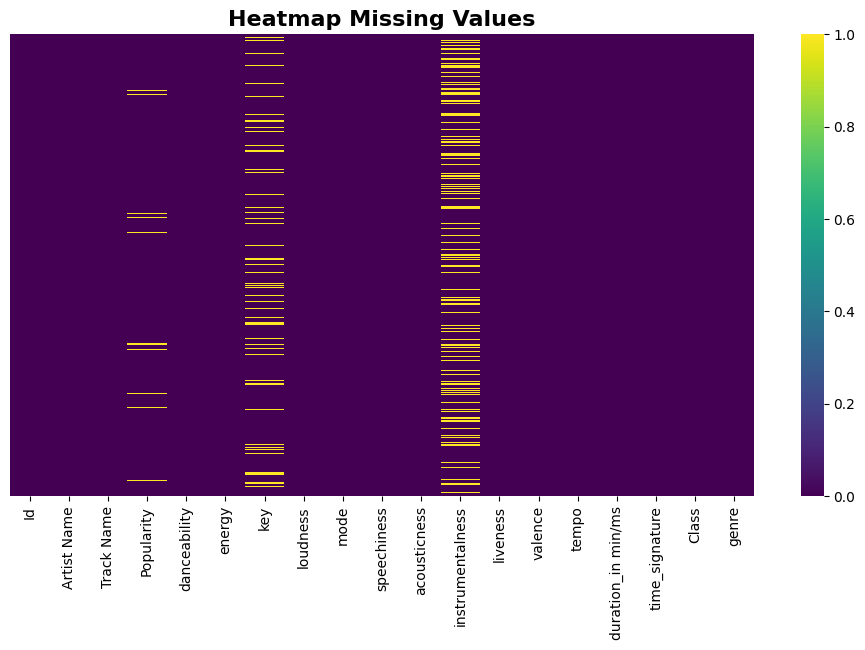

In [37]:
print("Tỷ lệ missing values (%):")
missing_percent = train.isnull().mean() * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)
print(missing_percent)

# Visualize missing values
plt.figure(figsize=(12, 6))
sns.heatmap(train.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Heatmap Missing Values', fontsize=16, fontweight='bold')
plt.show()

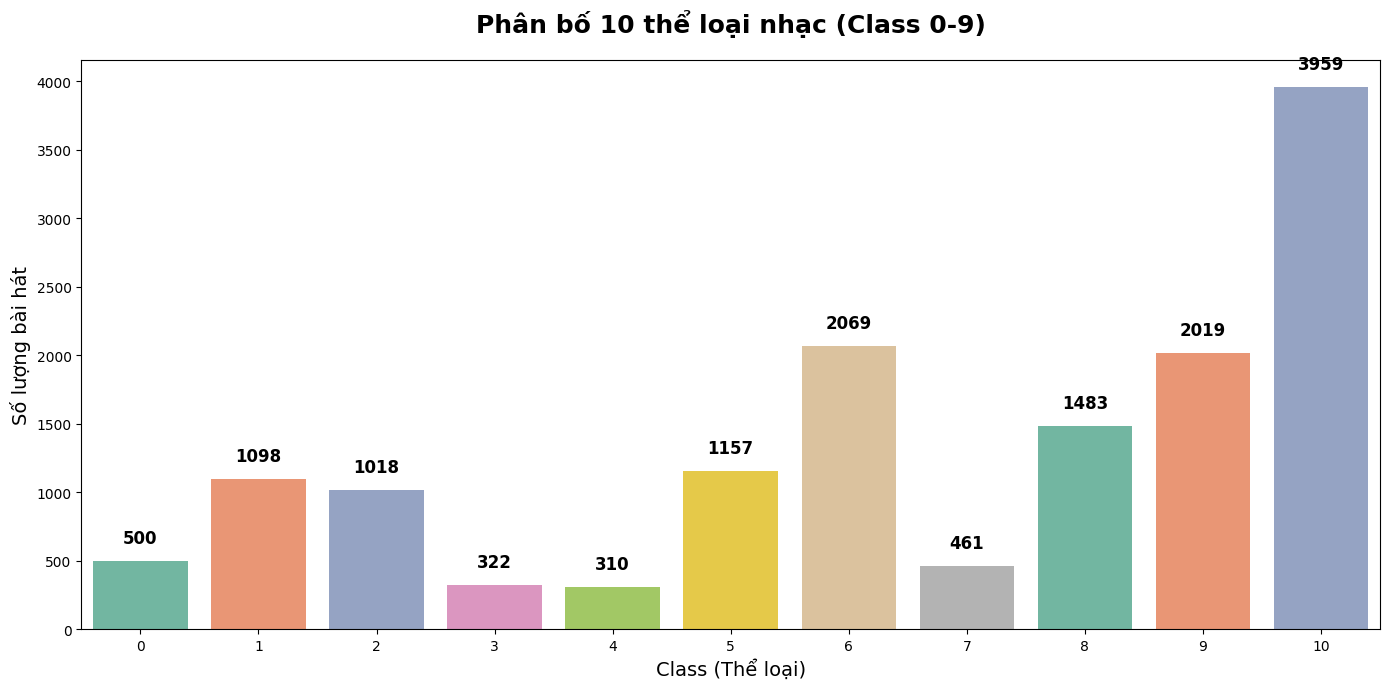

Số lượng từng Class:
Class
0      500
1     1098
2     1018
3      322
4      310
5     1157
6     2069
7      461
8     1483
9     2019
10    3959
Name: count, dtype: int64

Tỷ lệ từng Class (%):
Class
0      3.47
1      7.63
2      7.07
3      2.24
4      2.15
5      8.04
6     14.37
7      3.20
8     10.30
9     14.02
10    27.50
Name: count, dtype: float64


In [20]:
plt.figure(figsize=(14, 7))

# Đếm số lượng từng class
class_counts = train['Class'].value_counts().sort_index()

ax = sns.countplot(data=train, x='Class', hue='Class', order=class_counts.index, 
                   palette='Set2', legend=False)

plt.title('Phân bố 10 thể loại nhạc (Class 0-9)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Class (Thể loại)', fontsize=14)
plt.ylabel('Số lượng bài hát', fontsize=14)

# Thêm số lượng lên đầu mỗi cột
for i, v in enumerate(class_counts):
    ax.text(i, v + 100, str(v), ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

# In thông tin chi tiết
print("Số lượng từng Class:")
print(class_counts)
print("\nTỷ lệ từng Class (%):")
print((class_counts / len(train) * 100).round(2))

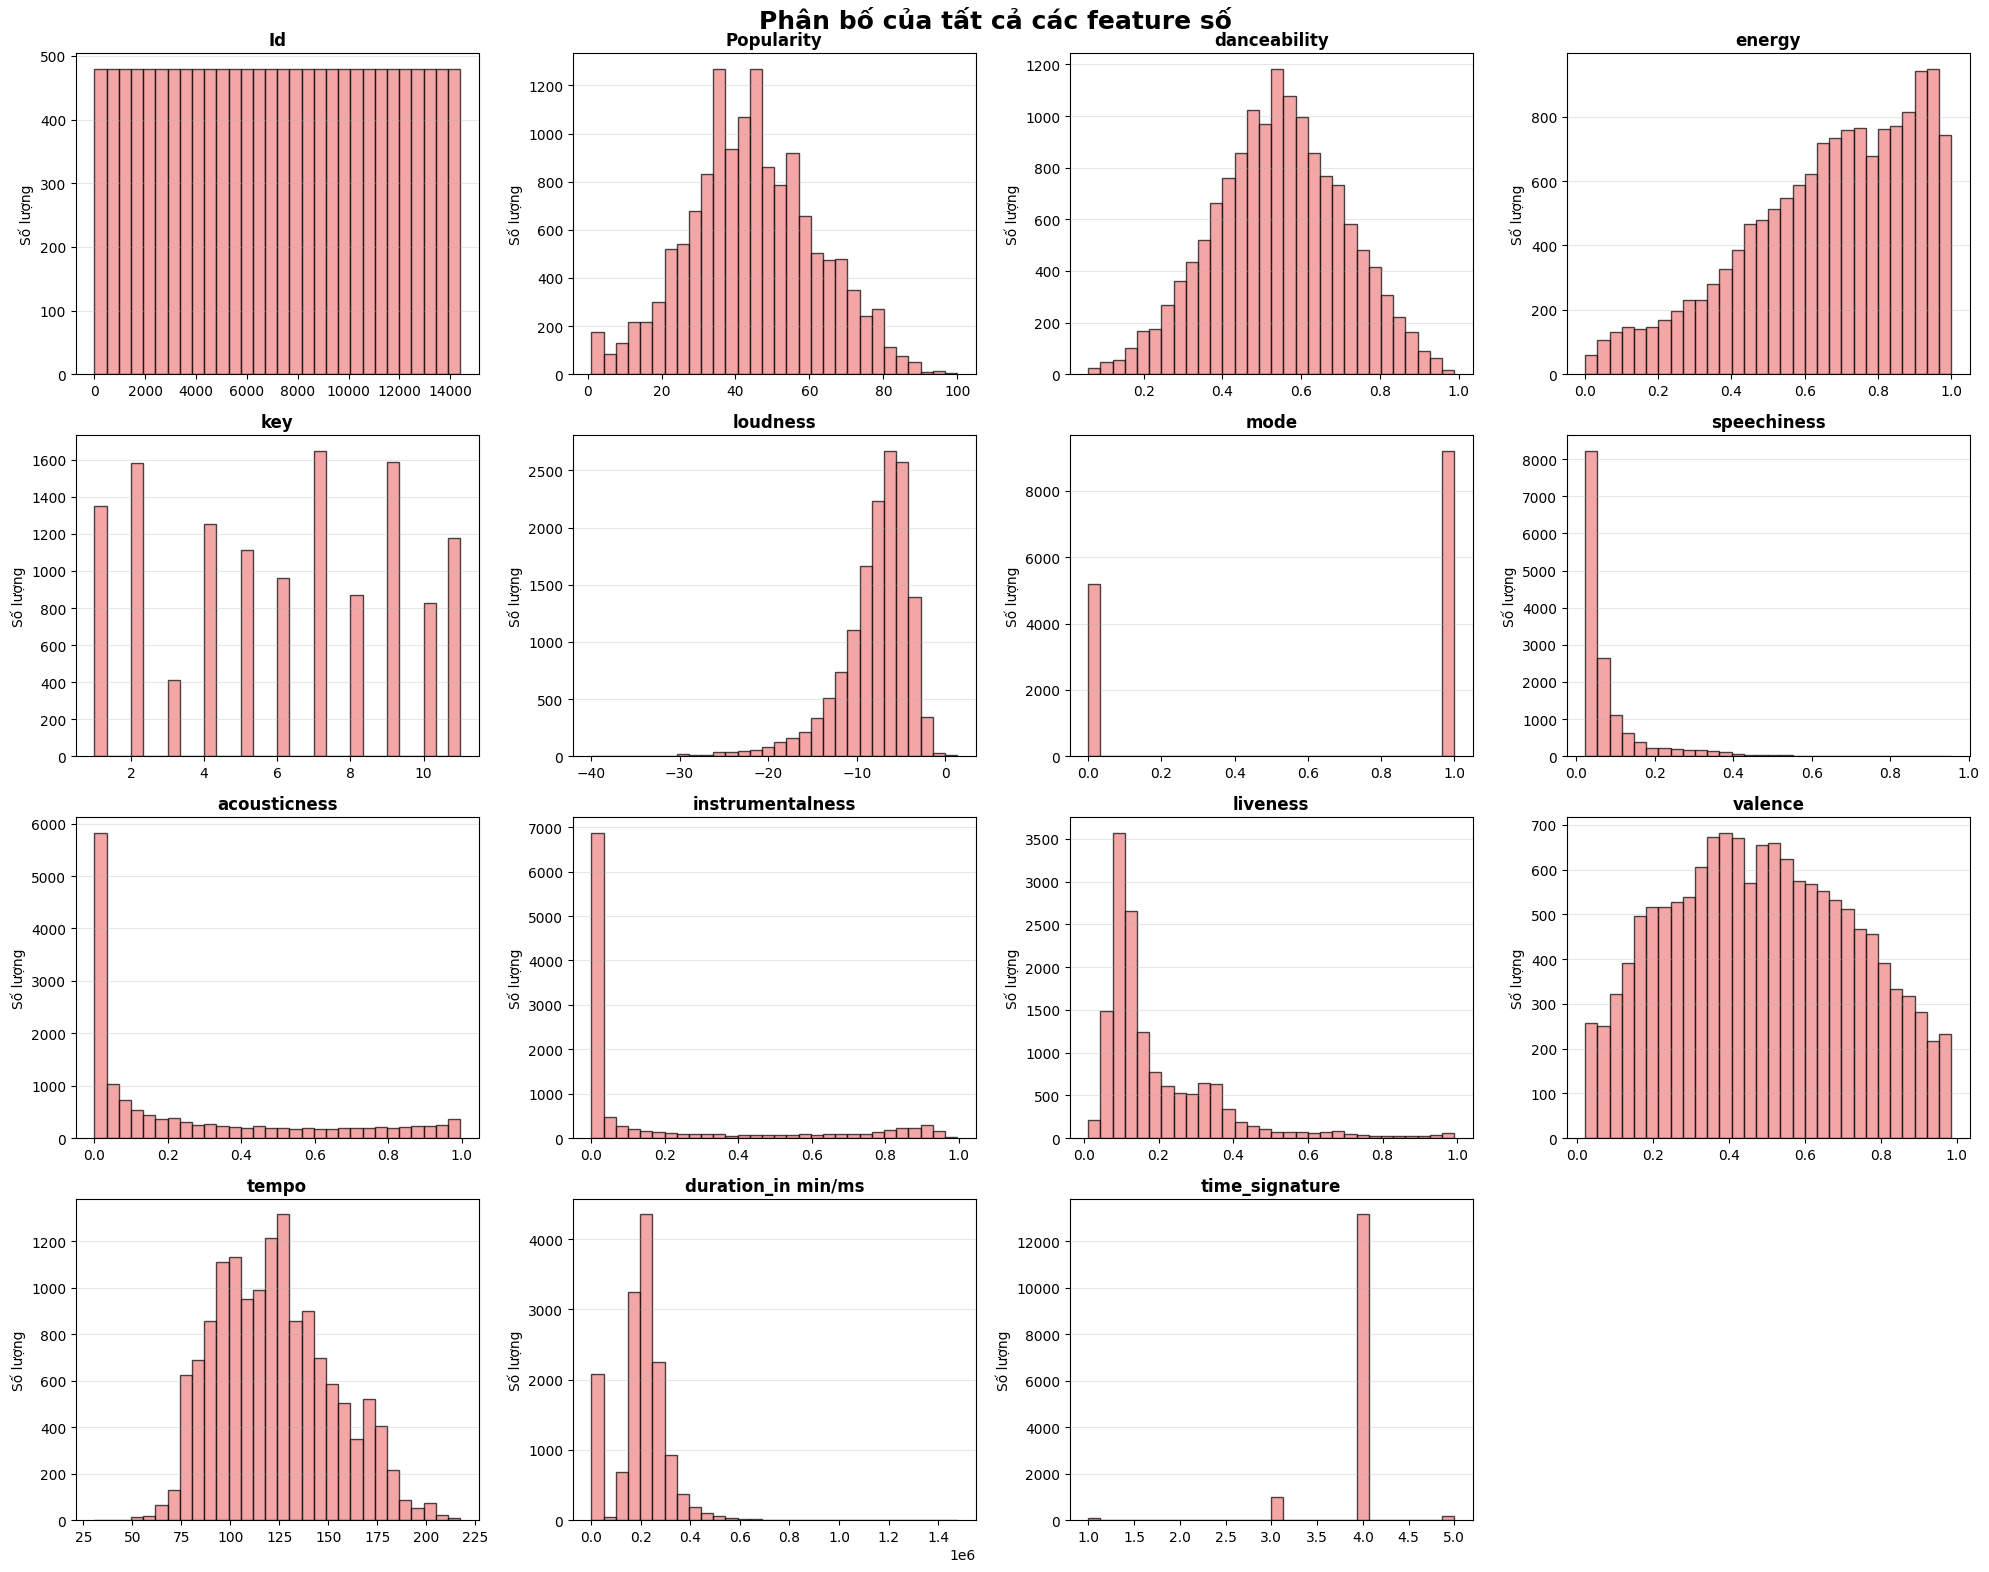

In [ ]:
# Lấy tất cả cột số (trừ Class và instance_id)
features = train.select_dtypes(include=['float64', 'int64']).columns
features = [col for col in features if col not in ['Class', 'instance_id']]

plt.figure(figsize=(20, 16))

for i, col in enumerate(features, 1):
    plt.subplot(4, 4, i)  # 4 hàng x 4 cột = 16 ô (đủ cho hết)
    plt.hist(train[col].dropna(), bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
    plt.title(f'{col}', fontsize=12, fontweight='bold')
    plt.xlabel('')
    plt.ylabel('Số lượng')
    plt.grid(axis='y', alpha=0.3)

plt.suptitle('Phân bố của tất cả các feature số', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


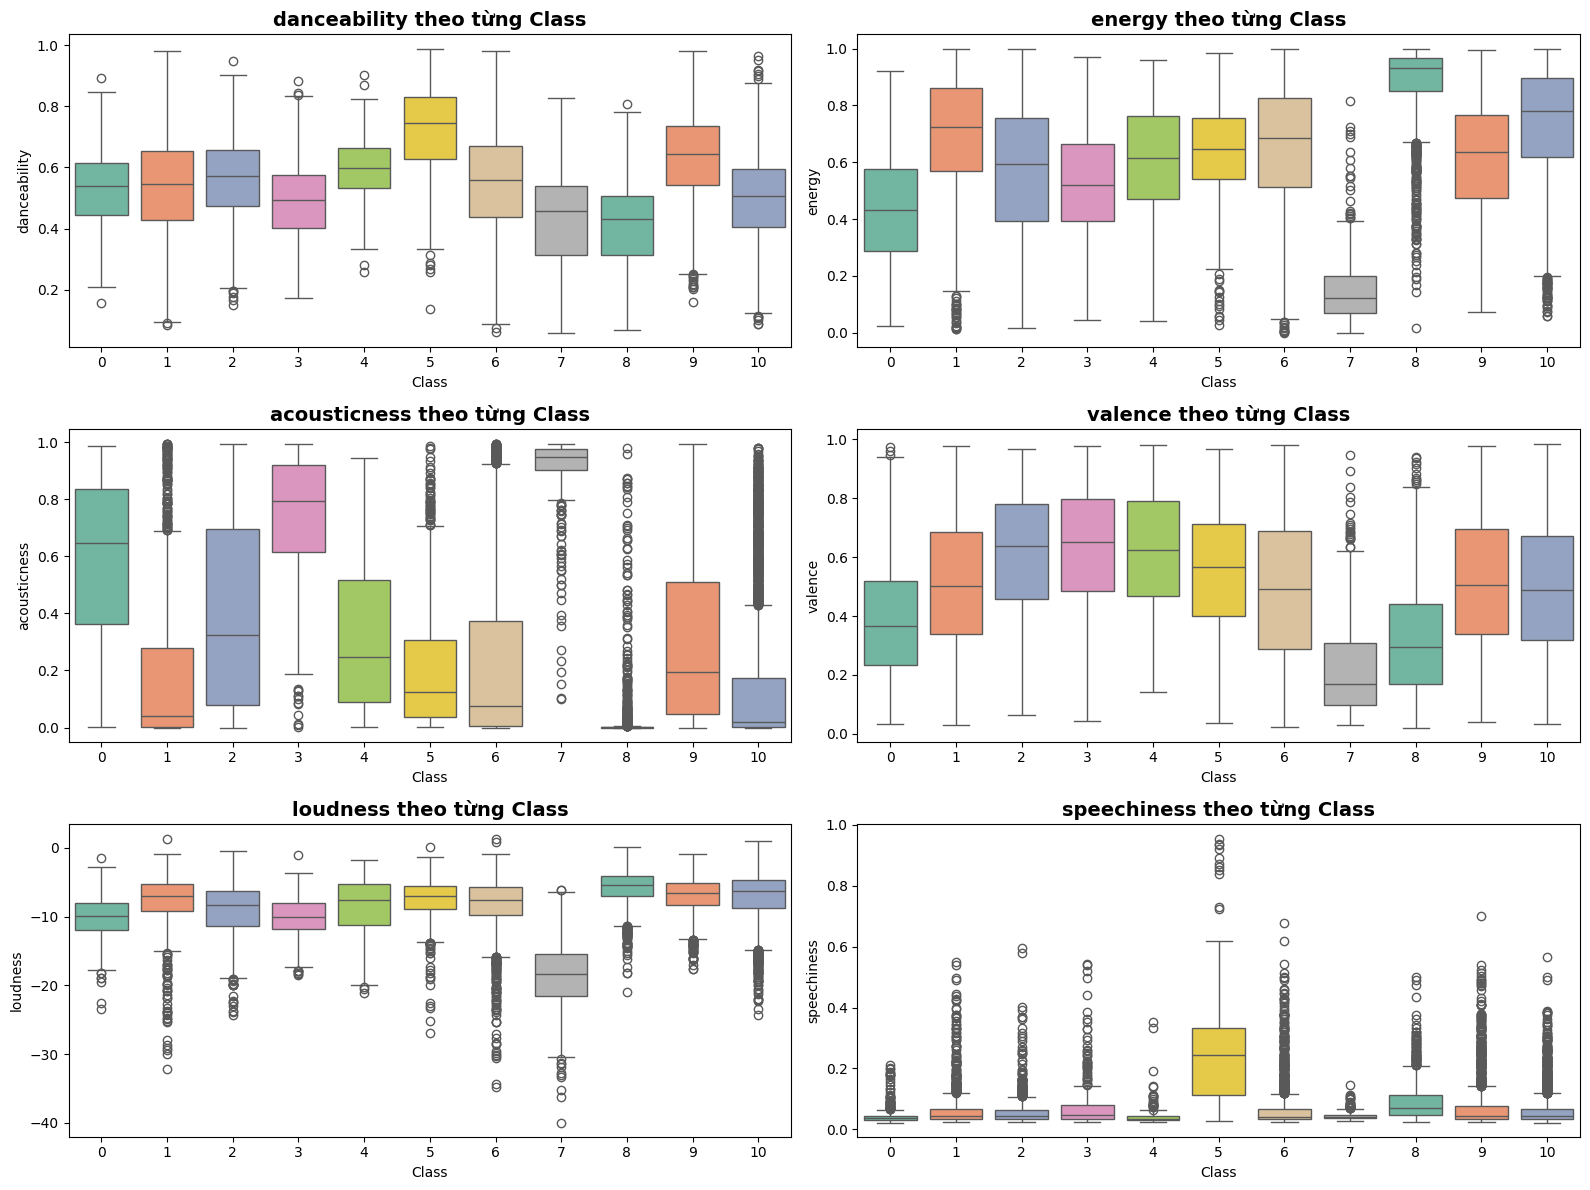

In [34]:
important_features = ['danceability', 'energy', 'acousticness', 'valence', 'loudness', 'speechiness']

plt.figure(figsize=(16, 12))

for i, col in enumerate(important_features, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(data=train, x='Class', y=col, hue='Class', palette='Set2', legend=False)
    plt.title(f'{col} theo từng Class', fontsize=14, fontweight='bold')
    plt.xlabel('Class')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

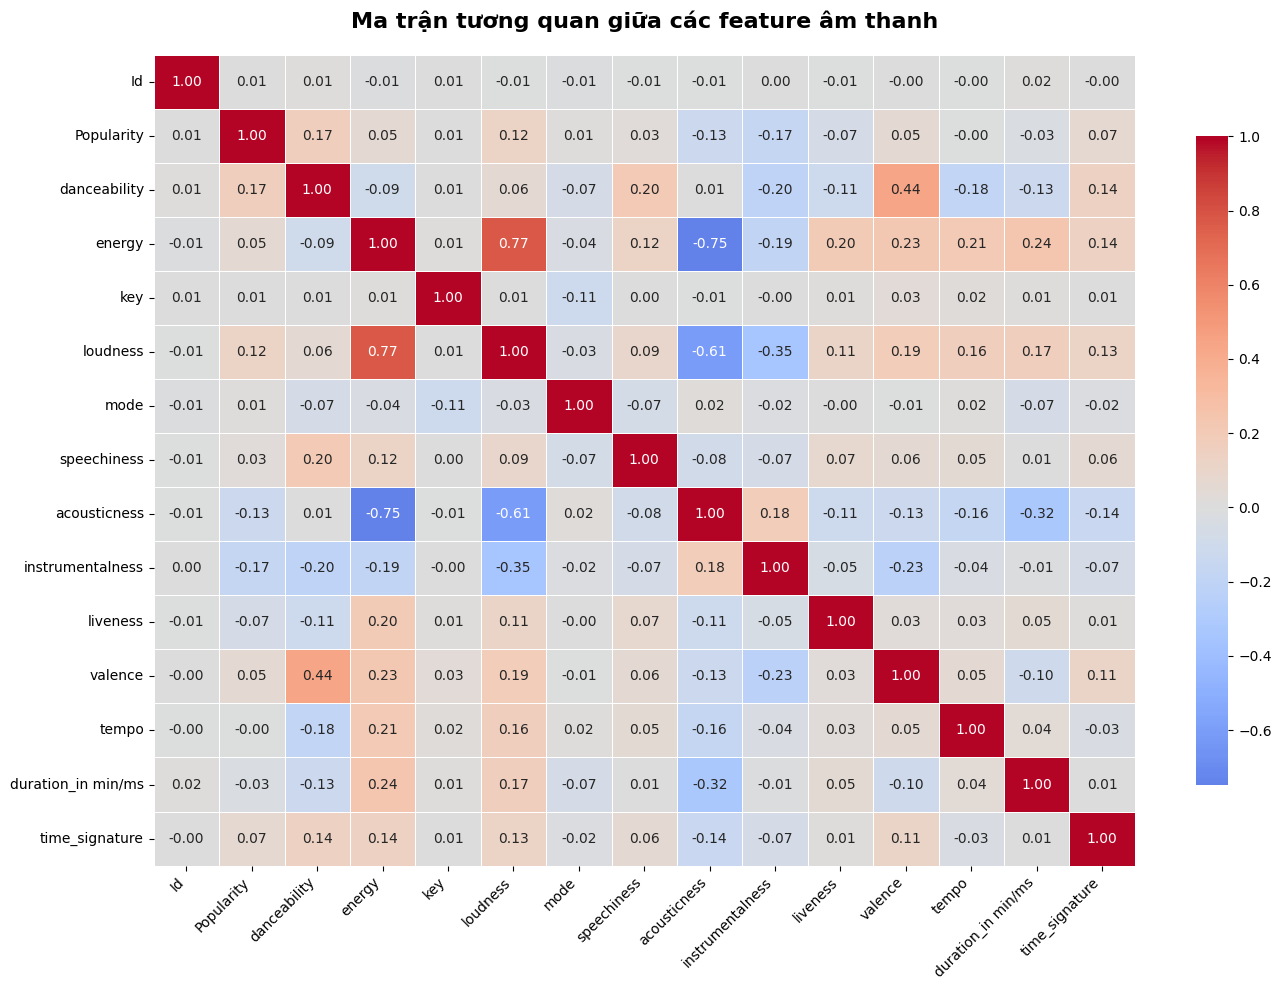

In [36]:
# Chỉ lấy các cột số (loại bỏ Class, instance_id)
numeric_cols = train.select_dtypes(include=['float64', 'int64']).columns
numeric_cols = numeric_cols.drop(['Class', 'instance_id'], errors='ignore')

plt.figure(figsize=(14, 10))
corr = train[numeric_cols].corr()

# Vẽ heatmap đẹp, có số rõ ràng
sns.heatmap(corr, 
            annot=True,      
            fmt='.2f',          
            cmap='coolwarm',   
            center=0,            
            linewidths=0.7, 
            cbar_kws={'shrink': 0.8},
            annot_kws={'size': 10})

plt.title('Ma trận tương quan giữa các feature âm thanh', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()